1. Import Libraries

In [7]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense


2.1 Creating Datasets

In [8]:
# Generate 2000 non-linear samples
X, y = make_moons(
    n_samples=2000,
    noise=0.12,
    random_state=42
)

# Create DataFrame in the same format as your image
df = pd.DataFrame({
    'X': X[:, 0],
    'Y': X[:, 1],
    'Class': y.astype(float)
})

df.head()

,X,Y,Class
0,1.750613,0.215969,1.0
1,0.388455,0.937320,0.0
2,0.494370,-0.308781,1.0
3,-0.947407,0.137360,0.0
4,0.504882,-0.348035,1.0


2.2 Visualize the Dataset

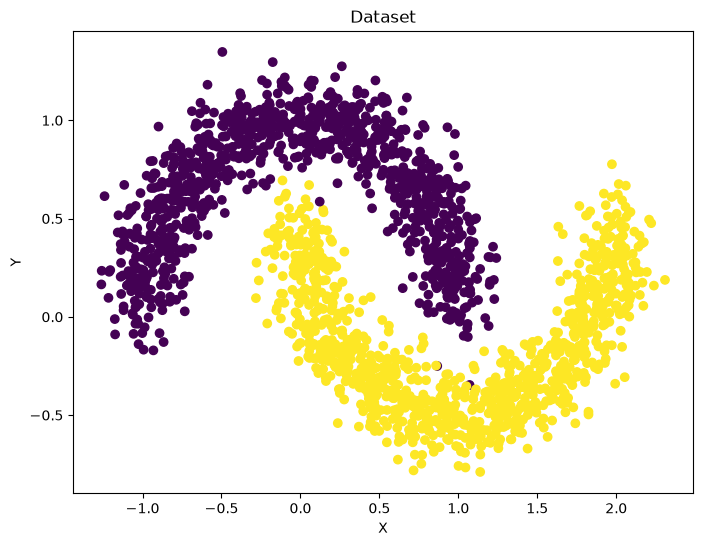

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['X'],
    df['Y'],
    c=df['Class']
)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dataset')
plt.show()

3. Separate Features and Target

In [10]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 2)
y shape: (2000,)


4. Create Neural Network with ReLU

In [11]:
model = Sequential()

model.add(
    Dense(
        2,
        activation='relu',
        input_shape=(2,)
    )
)

model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

e:\DL_by_CompusX\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5. Model Summary

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

6. Check Initial Weights

In [13]:
model.get_weights()

[array([[ 1.0350047 , -1.1232369 ],
        [ 0.49656534, -0.91255164]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.7766069],
        [-1.3717403]], dtype=float32),
 array([0.], dtype=float32)]

7. Store the Weights

In [14]:
initial_weights = model.get_weights()

8. Set All Weights and Biases to ZERO

In [15]:
initial_weights[0] = np.zeros(
    model.get_weights()[0].shape
)

initial_weights[1] = np.zeros(
    model.get_weights()[1].shape
)

initial_weights[2] = np.zeros(
    model.get_weights()[2].shape
)

initial_weights[3] = np.zeros(
    model.get_weights()[3].shape
)

9. Set Zero Weights in the Model

In [16]:
model.set_weights(initial_weights)

In [17]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

10. Compile the Model

In [19]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

11. Train the Model

In [20]:
history = model.fit(
    X,
    y,
    epochs=100,
    validation_split=0.2
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5113 - loss: 0.6931 - val_accuracy: 0.4550 - val_loss: 0.6936
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5113 - loss: 0.6931 - val_accuracy: 0.4550 - val_loss: 0.6937
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5113 - loss: 0.6930 - val_accuracy: 0.4550 - val_loss: 0.6940
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5113 - loss: 0.6930 - val_accuracy: 0.4550 - val_loss: 0.6942
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5113 - loss: 0.6930 - val_accuracy: 0.4550 - val_loss: 0.6943
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5113 - loss: 0.6930 - val_accuracy: 0.4550 - val_loss: 0.6944
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5113 - loss: 0.6929 - val_accuracy: 0.4550 - val_loss: 0.6946
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5113 - loss: 0.6930 - val_accuracy: 0.4550 - v

12. Check the Weights After Training

In [21]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([-0.04525676], dtype=float32)]

13. Check the Predictions

In [22]:
predictions = model.predict(X, verbose=0)

predictions[:10]

array([[0.48868772],
       [0.48868772],
       [0.48868772],
       [0.48868772],
       [0.48868772],
       [0.48868772],
       [0.48868772],
       [0.48868772],
       [0.48868772],
       [0.48868772]], dtype=float32)

14. Plot Training Loss

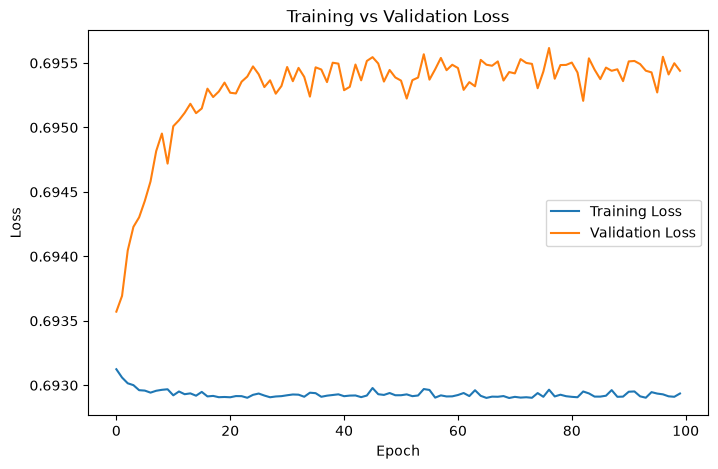

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.show()

15. Plot Accuracy

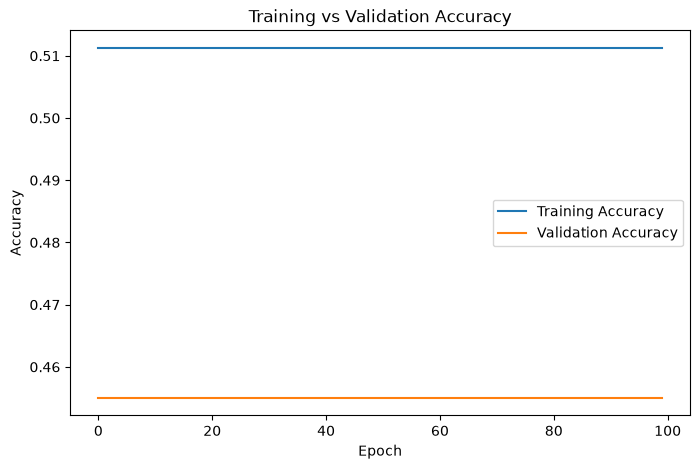

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.show()

16. Decision Boundary

In [25]:
from mlxtend.plotting import plot_decision_regions

class MyModel:

    def __init__(self, model):
        self.model = model

    def predict(self, X):
        pred = self.model.predict(
            X,
            verbose=0
        )

        return (
            pred >= 0.5
        ).astype(int).ravel()

17. Create Classifier

In [27]:
clf = MyModel(model)

18. Plot Decision Regions

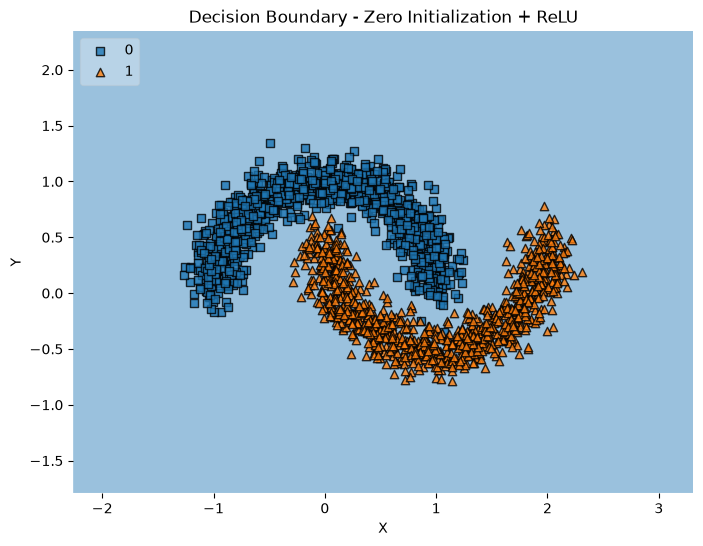

In [28]:
plt.figure(figsize=(8, 6))

plot_decision_regions(
    X,
    y.astype(int),
    clf=clf,
    legend=2
)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Decision Boundary - Zero Initialization + ReLU')

plt.show()